# Tutorial 07 - BME in the Space-Time Domain

**Package:** stamps_v3  
**MATLAB equivalent:** `BMEPROBALIBtutorial.m` (Part 2 - space-time domain)  
**Dataset:** Synthetic space-time dataset

---

## Learning objectives

1. Extend the spatial framework to **space-time** (2D space + time).
2. Build a **separable space-time covariance model** using the `/` notation, e.g. `'sphericalC/exponentialC'`.
3. Prepare space-time coordinates and data with `valstv2stg` / `valstg2stv`.
4. Choose BME neighbourhood parameters (`nhmax`, `dmax_space`) relative to the covariance range.
5. Run BME posterior moments for a specific **time slice** using `BMEPosteriorMoments`.
6. Visualise BME mean and variance maps for the target time.

### Why domain size and data density matter

For BME (and kriging) to produce informative estimates the data must be **within the correlation range** of each estimation node. Key rules of thumb:

| Rule | Guideline |
|---|---|
| Domain size | ≲ 3–4 × `a_s` per side |
| `dmax_space` | ≈ 2 × `a_s` |
| Hard data density | ≥ 1 point per `a_s × a_s` area (per time slice) |
| `order` | `0` (ordinary kriging) unless a known trend exists |

If the domain is much larger than `a_s` and data density is low, BME has no information at many nodes and returns the prior mean (zero), making estimates appear flat/zero.

### Space-time coordinates in stamps_v3

Space-time data requires **3-column coordinate arrays**: `[easting, northing, time]`.  The `dmax` parameter becomes a 3-element vector `[dmax_space, dmax_time, st_ratio]`:

- `dmax_space` — maximum spatial search radius (metres)
- `dmax_time`  — maximum temporal search radius (time units)
- `st_ratio`   — scale factor converting time to spatial units


In [1]:
import os, pickle
import numpy as np
import matplotlib.pyplot as plt


from stamps.stats.simulation.simulation import simuchol
from stamps.bme.softconverter import probaGaussian, probaUniform
from stamps.bme.BMEprobaEstimations import BMEPosteriorMoments

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
DATA_DIR = os.path.join(os.getcwd(), 'data')

# Load covariance model from Tutorial 03
with open(os.path.join(DATA_DIR, 'tutorial03_cov.pkl'), 'rb') as f:
    cov = pickle.load(f)
covmodel_space = cov['sand_covmodel']
covparam_space = cov['sand_covparam']

print('Spatial covariance model:', covmodel_space)


Spatial covariance model: ['nuggetC', 'sphericalC']


## 1. Build the space-time covariance model

A **separable** space-time covariance model factors into an independent product of a spatial and a temporal component:

$$C(h_s, h_t) = C_s(h_s) \cdot C_t(h_t)$$

In stamps_v3, separable models use the **forward-slash `/` notation**: the spatial model name and temporal model name are joined by `/` within each nested component:

| Nested component | stamps model string | params tuple |
|---|---|---|
| Nugget | `'nuggetC/nuggetC'` | `(sill, None, None)` |
| Exponential | `'exponentialC/exponentialC'` | `(sill, ar_space, ar_time)` |

`coord2K` detects the `/` and evaluates the two models on separate spatial and temporal distances:
$$C_i(h_s, h_t) = \text{sill}_i \cdot M_s(h_s, \text{ar}_s) \cdot M_t(h_t, \text{ar}_t)$$

**`dmax` for space-time** still requires three elements `[dmax_space, dmax_time, st_ratio]`:
`st_ratio = ar_space / ar_time` normalises time into spatial units so that the KD-tree neighbourhood search uses a single consistent metric.


In [2]:
# Separable space-time covariance model
# Use the SAME spatial model as the simulation (sphericalC) to avoid model
# mismatch.  Temporal component: exponentialC with range a_t.

# Covariance sill and ranges from Tutorial 03 + temporal extension
c_nugget = float(covparam_space[0][0])  # nugget sill
c_sill   = float(covparam_space[1][0])  # spatial sill
a_s      = float(np.asarray(covparam_space[1][1]).ravel()[0])  # spatial range [m]

# Temporal model parameters
a_t      = 2.0      # temporal range [days]
st_ratio = a_s / a_t  # spatial-to-temporal ratio (m/day)

# Separable space-time covariance model: C(hs, ht) = Cs(hs) * Ct(ht)
#
# Model format: 'spatialModelName/temporalModelName'
#   The '/' tells coord2K to apply the two models to spatial and temporal
#   distances independently, then multiply the results (separable product).
#
# Parameter format for each nested component: (sill, ar_space, ar_time)
#   coord2K unpacks: sill, param_s, param_t = param_i
#   and evaluates:   sill * Cs(dist_s, 1, ar_space) * Ct(dist_t, 1, ar_time)
#   For the nugget, ar_space = None and ar_time = None (no range).
#
# IMPORTANT: we use 'sphericalC/exponentialC' so the spatial component matches
# the sphericalC model that was fitted in Tutorial 03 and used to SIMULATE the
# data.  Using the wrong spatial model (e.g. exponentialC) causes a systematic
# mismatch between the assumed covariance and the actual data structure, which
# degrades estimation accuracy.
covmodel_st = ['nuggetC/nuggetC', 'sphericalC/exponentialC']
covparam_st = [
    (c_nugget, None, None),  # nugget:    (sill, ar_space=None, ar_time=None)
    (c_sill,   a_s,  a_t),   # structure: (sill, ar_space [m], ar_time [days])
]

print('Space-time covariance model:', covmodel_st)
print(f'  Nugget : {c_nugget:.3f}')
print(f'  Sill   : {c_sill:.3f}')
print(f'  Spatial range : {a_s:.0f} m  (sphericalC)')
print(f'  Temporal range: {a_t:.1f} days  (exponentialC)')
print(f'  ST ratio      : {st_ratio:.1f} m/day')


Space-time covariance model: ['nuggetC/nuggetC', 'sphericalC/exponentialC']
  Nugget : 6.000
  Sill   : 69.495
  Spatial range : 2844 m  (sphericalC)
  Temporal range: 2.0 days  (exponentialC)
  ST ratio      : 1422.2 m/day


## 2. Simulate a space-time dataset

We create a synthetic space-time field over a 10 x 10 spatial grid observed at 5 time steps (Days 1-5).

**Implementation approach:**  
We simulate the spatial field at each time step independently using `simuchol`, adding temporal correlation by a simple AR(1) model:

$$Z(s, t) = \rho \cdot Z(s, t-1) + \sqrt{1-\rho^2} \cdot \varepsilon(s, t)$$


Simulated field shape: (100, 5)  (100 locations x 5 times)
Global mean : -3.8696
Global var  : 59.2509


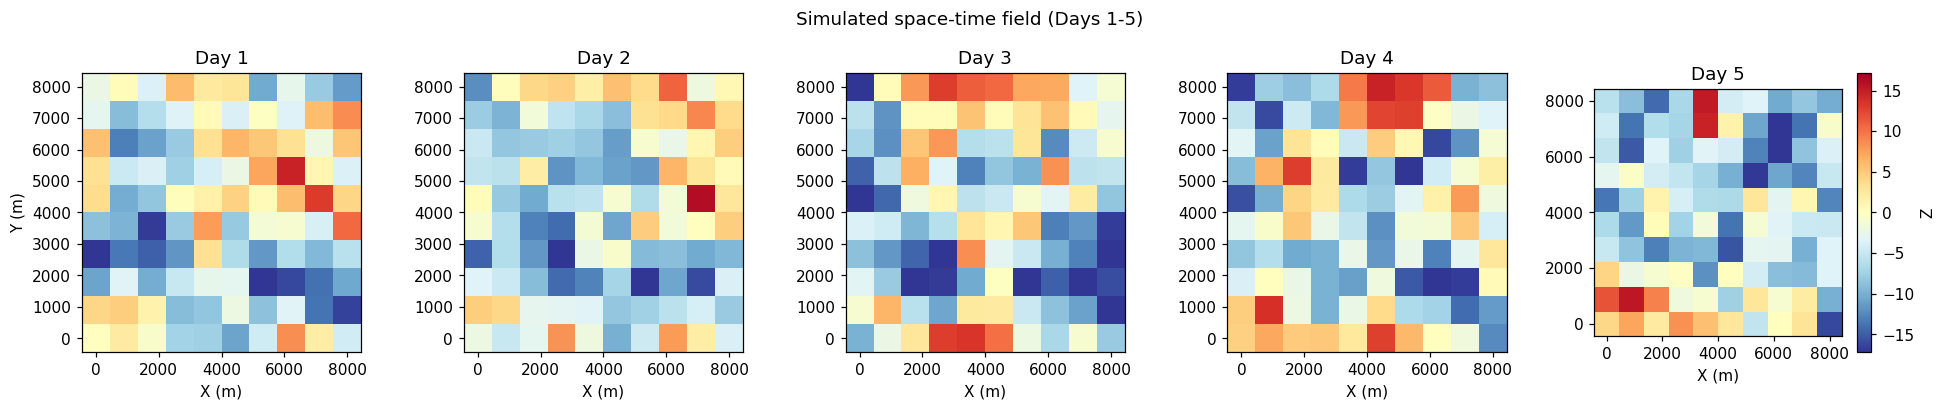

In [3]:
rng = np.random.default_rng(seed=7)

# Spatial grid
# Domain size MUST be comparable to the correlation range (a_s) so that
# data points have adequate influence over the estimation grid.
# Rule of thumb: domain ≲ 3 × a_s in each direction.
#   a_s ≈ 2 844 m  →  domain ≈ 3 × 2 844 ≈ 8 500 m  →  use 8 000 m.
# A domain of 20 000 × 14 000 m with a_s ≈ 2 844 m spans 7 × 5 correlation
# ranges, leaving most estimation nodes far from any data and causing BME to
# return the prior mean (≈ 0) everywhere.
nx_st, ny_st = 10, 10
x_st = np.linspace(0, 8_000, nx_st)
y_st = np.linspace(0, 8_000, ny_st)
XX_st, YY_st = np.meshgrid(x_st, y_st)
spatial_grid = np.column_stack([XX_st.ravel(), YY_st.ravel()])  # (100, 2)

n_space = len(spatial_grid)
n_time  = 5                     # Days 1 to 5
times   = np.arange(1, n_time + 1, dtype=float)

# Temporal AR(1) correlation
rho = np.exp(-1.0 / a_t)        # AR(1) coefficient

# Simulate using spatial Cholesky + AR(1) in time
Z_st = np.zeros((n_space, n_time))
eps0, _ = simuchol(spatial_grid, covmodel_space, covparam_space, ns=1, seed=rng)
Z_st[:, 0] = eps0[:, 0]
for t in range(1, n_time):
    eps_t, _ = simuchol(spatial_grid, covmodel_space, covparam_space, ns=1, seed=rng)
    Z_st[:, t] = rho * Z_st[:, t - 1] + np.sqrt(1 - rho**2) * eps_t[:, 0]

print(f'Simulated field shape: {Z_st.shape}  ({n_space} locations x {n_time} times)')
print(f'Global mean : {Z_st.mean():.4f}')
print(f'Global var  : {Z_st.var():.4f}')

# Plot all time slices
fig, axes = plt.subplots(1, n_time, figsize=(18, 3.5))
vz = np.percentile(np.abs(Z_st), 97)
for t_i, ax in enumerate(axes):
    Z_map = Z_st[:, t_i].reshape(ny_st, nx_st)
    im = ax.pcolormesh(x_st, y_st, Z_map, cmap='RdYlBu_r',
                       vmin=-vz, vmax=vz, shading='nearest')
    ax.set_title(f'Day {t_i+1}')
    ax.set_aspect('equal')
    if t_i == 0:
        ax.set_ylabel('Y (m)')
    ax.set_xlabel('X (m)')
plt.colorbar(im, ax=axes[-1], label='Z')
plt.suptitle('Simulated space-time field (Days 1-5)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 3. Prepare space-time data

Hard data: exact observations at 25 randomly selected space-time points.  
Soft data: noisy Gaussian observations at 20 other space-time points.  
Estimation target: Day 3 (time = 3) over the full spatial grid.


In [4]:
# Build all space-time observations as (x, y, t) tuples
n_pts_total = n_space * n_time
# Create full space-time coordinate array
all_coords_st = []
all_vals_st   = []
for t_i, t_val in enumerate(times):
    for s_i in range(n_space):
        all_coords_st.append([spatial_grid[s_i, 0],
                              spatial_grid[s_i, 1],
                              t_val])
        all_vals_st.append(Z_st[s_i, t_i])

all_coords_st = np.array(all_coords_st)  # (500, 3)
all_vals_st   = np.array(all_vals_st)    # (500,)

# Random split into hard and soft data
# Use 50 hard data (≈10/time slice) to ensure adequate spatial coverage in the
# 8 000 × 8 000 m domain (≈ 3 × a_s wide).  Too few data leaves estimation
# nodes far from any observation, causing BME to return the prior mean.
idx_all_st   = rng.permutation(n_pts_total)
n_hard_st    = 50
n_soft_st    = 20
idx_hard_st  = idx_all_st[:n_hard_st]
idx_soft_st  = idx_all_st[n_hard_st:n_hard_st + n_soft_st]

ch_st = all_coords_st[idx_hard_st]    # (n_hard, 3)
zh_st = all_vals_st[idx_hard_st]      # (n_hard,)

cs_st = all_coords_st[idx_soft_st]    # (n_soft, 3)
noise_s = 1.5
z_soft_st_mean = all_vals_st[idx_soft_st] + rng.normal(0, noise_s, n_soft_st)
z_soft_st_std  = noise_s * np.ones(n_soft_st)
# NOTE: probaGaussian(zm, zv) expects *variance* (zv = std²), not standard deviation.
z_soft_st_var  = noise_s**2 * np.ones(n_soft_st)

# Encode Gaussian soft data
zs_st = probaGaussian(z_soft_st_mean, z_soft_st_var)

# Estimation grid: target Day 3
target_time = 3.0
ck_st = np.column_stack([
    spatial_grid,
    target_time * np.ones(n_space)
])  # (n_space, 3)

# True values at target time for verification
t_idx = np.where(times == target_time)[0][0]
z_true_day3 = Z_st[:, t_idx]

print(f'Hard data    : {n_hard_st} space-time points')
print(f'Soft data    : {n_soft_st} space-time points')
print(f'Estimation   : {n_space} locations at Day {target_time:.0f}')


Hard data    : 50 space-time points
Soft data    : 20 space-time points
Estimation   : 100 locations at Day 3


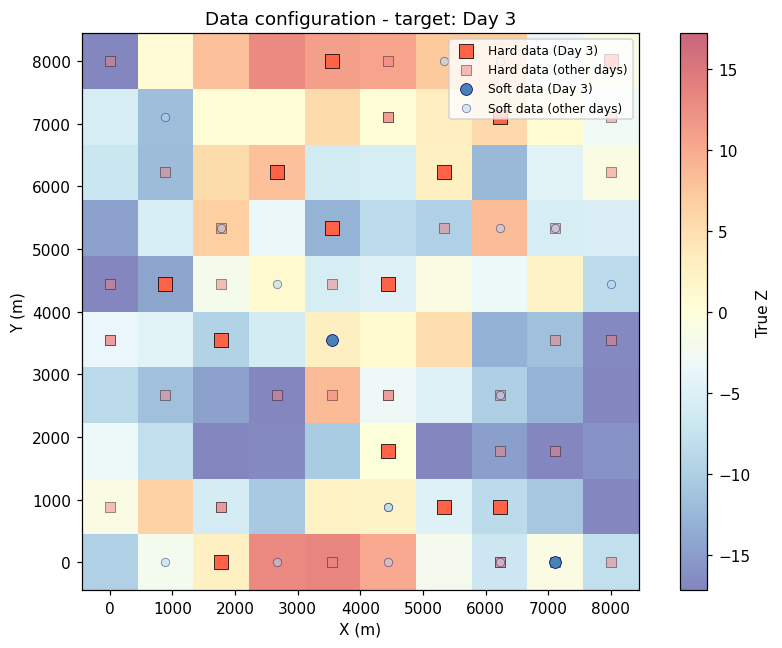

In [5]:
# Visualise data configuration for Day 3
day3_mask_h = ch_st[:, 2] == target_time
day3_mask_s = cs_st[:, 2] == target_time

fig, ax = plt.subplots(figsize=(8, 6))
Z_true_map = z_true_day3.reshape(ny_st, nx_st)
im = ax.pcolormesh(x_st, y_st, Z_true_map, cmap='RdYlBu_r',
                   vmin=-vz, vmax=vz, shading='nearest', alpha=0.6)
plt.colorbar(im, ax=ax, label='True Z')
ax.scatter(ch_st[day3_mask_h, 0], ch_st[day3_mask_h, 1],
           c='tomato', s=80, marker='s', edgecolors='k', lw=0.5,
           zorder=4, label='Hard data (Day 3)')
ax.scatter(ch_st[~day3_mask_h, 0], ch_st[~day3_mask_h, 1],
           c='lightcoral', s=40, marker='s', edgecolors='k', lw=0.5,
           alpha=0.5, zorder=3, label='Hard data (other days)')
ax.scatter(cs_st[day3_mask_s, 0], cs_st[day3_mask_s, 1],
           c='steelblue', s=60, marker='o', edgecolors='navy', lw=0.5,
           zorder=4, label='Soft data (Day 3)')
ax.scatter(cs_st[~day3_mask_s, 0], cs_st[~day3_mask_s, 1],
           c='lightblue', s=30, marker='o', edgecolors='navy', lw=0.5,
           alpha=0.5, zorder=3, label='Soft data (other days)')
ax.set_title('Data configuration - target: Day 3')
ax.set_aspect('equal')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()


## 4. BME posterior moments at Day 3

We pass the **space-time search neighbourhood** via `dmax` as a **3-element vector**:

```python
dmax = np.array([[dmax_space, dmax_time, st_ratio]])
```

- `dmax_space` — maximum spatial search radius (metres)  
- `dmax_time`  — maximum temporal search radius (time units)  
- `st_ratio`   — spatial-to-temporal conversion factor (metres / time unit)

The internal engine computes a combined distance `d = h_s + st_ratio * h_t`, so all three values are required when coordinates are 3-column `[x, y, t]` arrays.  The `covmodel` uses the CST (combined space-time) format.


In [6]:
# Space-time neighbourhood parameters
# dmax_space: limit to ~2 × a_s so we include correlated neighbours but
#   exclude distant points that only add noise.  Using 15 000 m (5× a_s)
#   was including decorrelated data and making the system ill-conditioned.
# nhmax_st: increase to 20 since we now have more data (50 hard points).
# order=0: ordinary-kriging prior — BME estimates the local mean from
#   neighbours instead of assuming zero, which avoids "reverts to 0" in
#   areas with sparse data.
nhmax_st   = 20
nsmax_st   = 10
dmax_space = 2.0 * a_s  # ~2 × spatial range  (≈ 5 700 m)
dmax_time  = 2.5         # 2.5 day temporal search
# dmax for space-time must be a 3-element row: [dmax_space, dmax_time, st_ratio]
# st_ratio converts time units to spatial units (combined metric: d = h_s + st_ratio * h_t)
dmax_st    = np.array([[dmax_space, dmax_time, st_ratio]])

print('Running space-time BME for Day 3...')
print(f'  nhmax={nhmax_st}, nsmax={nsmax_st}')
print(f'  dmax_space={dmax_space:.0f} m ({dmax_space/a_s:.1f}×a_s), dmax_time={dmax_time:.1f} days')

result_st = BMEPosteriorMoments(
    ck_st,
    ch=ch_st, cs=cs_st,
    zh=zh_st.reshape(-1, 1),
    zs=tuple(zs_st),
    covmodel=covmodel_st,
    covparam=covparam_st,
    order=0,      # ordinary kriging: estimate local mean from neighbours
    nhmax=nhmax_st, nsmax=nsmax_st,
    dmax=dmax_st,
)

bme_st_mean = result_st[:, 0]
bme_st_var  = result_st[:, 1]

valid_st = ~np.isnan(bme_st_mean)
rmse_st  = np.sqrt(np.mean((bme_st_mean[valid_st] - z_true_day3[valid_st])**2))
print(f'\nBME estimated {valid_st.sum()} / {n_space} nodes')
print(f'RMSE vs truth: {rmse_st:.4f}')
print(f'Mean variance: {np.nanmean(bme_st_var):.4f}')


Running space-time BME for Day 3...
  nhmax=20, nsmax=10
  dmax_space=5689 m (2.0×a_s), dmax_time=2.5 days
preparing...done
[STARBME] BME estimation: nk=100, nh=50, ns=20, soft types={2}, approx_gaussian=False
[STARBME] WARNING: Non-Gaussian soft data detected. Using QMC integration (slow). Enable 'Fast Gaussian Approximation' in Prediction > Configures for speed-up.


/Users/hdragon689/Documents/MyDoc_iCloud/packages/stamps/stamps_v3/stamps/bme/BMEprobaEstimations.py:807: UserWarning: [STARBME] Covariance-based near-duplicate detection: 1 ck point(s) nearly co-located with cs. Routing to analytical dup path.
  warnings.warn(


100 / 100
[STARBME] BME estimation completed in 1.4s (0.014s per point)
[STARBME] QMC noise diagnostic: delta_mu  median=0.003983, max=0.01722; rel_err  median=0.13%, max=0.86% (98 of 100 points had QMC error info)

BME estimated 100 / 100 nodes
RMSE vs truth: 7.1824
Mean variance: 50.8741


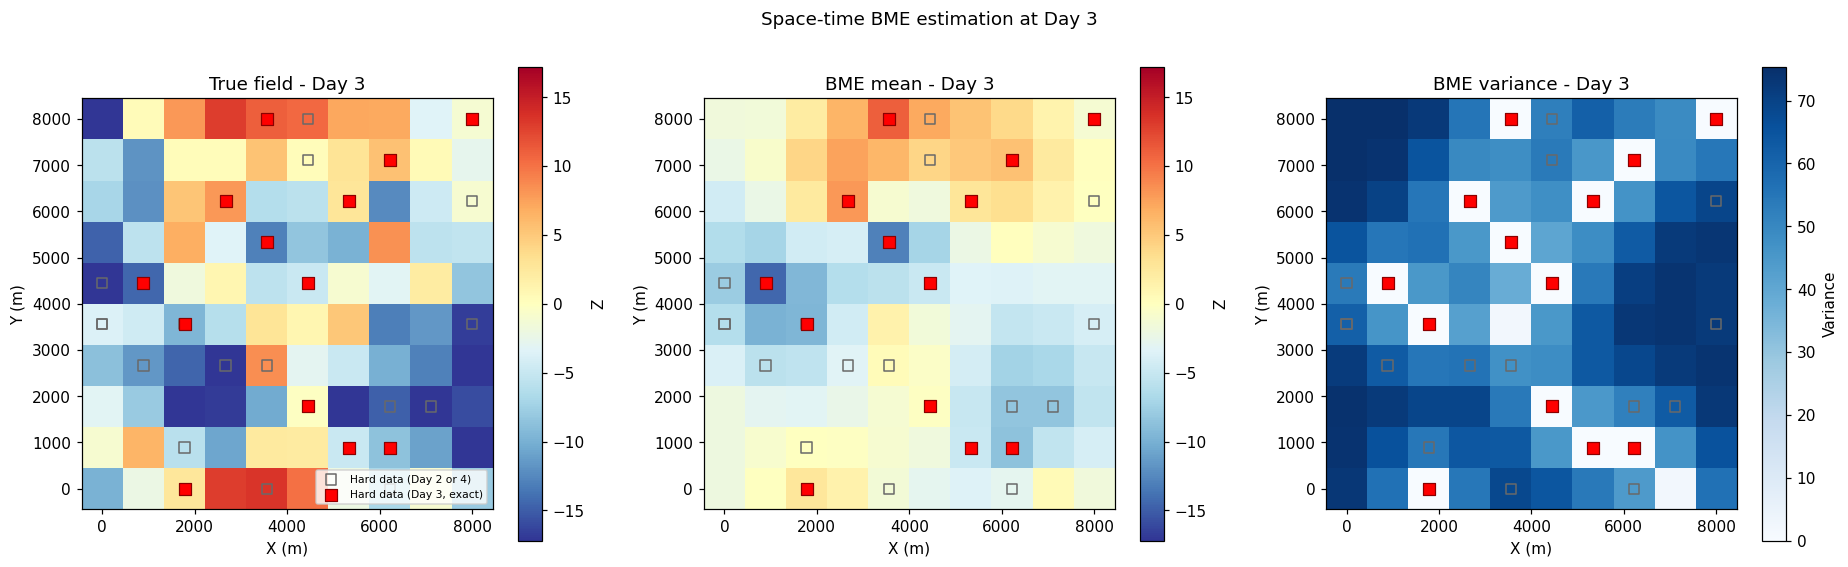

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

def show_st_map(ax, z_vals, title, cmap='RdYlBu_r', vmin=None, vmax=None, cbar_label='Z'):
    Z_map = z_vals.reshape(ny_st, nx_st)
    vm = vmin if vmin is not None else np.nanpercentile(z_vals, 2)
    vx = vmax if vmax is not None else np.nanpercentile(z_vals, 98)
    im = ax.pcolormesh(x_st, y_st, Z_map, cmap=cmap,
                       vmin=vm, vmax=vx, shading='nearest')
    plt.colorbar(im, ax=ax, label=cbar_label)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')

show_st_map(axes[0], z_true_day3, 'True field - Day 3',  vmin=-vz, vmax=vz)
show_st_map(axes[1], bme_st_mean, 'BME mean - Day 3',    vmin=-vz, vmax=vz)
show_st_map(axes[2], bme_st_var,  'BME variance - Day 3', cmap='Blues',
            cbar_label='Variance')

# -----------------------------------------------------------------------
# Mark hard data with time-coded markers so that Day 3 vs other-day data
# are clearly distinguishable.
#
# WHY THIS MATTERS (variance checkerboard pattern)
# -------------------------------------------------
# An estimation node at (x, y, Day 3) is a *different* space-time point
# from hard data at (x, y, Day 2).  Temporal correlation at 1 day apart:
#   C_t(1) = exp(-1 / a_t) = exp(-0.5) ≈ 0.61
# This gives a residual variance at that node of ≈ 52 (out of prior 75),
# even though the hard data appears spatially "on top of" the node.
# Only Day 3 hard data sitting exactly at a grid node can reduce variance
# to ≈ nugget (≈ 6) via the kriging interpolation property.
# -----------------------------------------------------------------------
mask_day3   = ch_st[:, 2] == target_time            # exact Day 3
mask_adj    = (np.abs(ch_st[:, 2] - target_time) <= 1.5) & ~mask_day3  # Day 2 or 4

for ax in axes:   # mark on all three panels
    # Adjacent-day data: hollow grey squares
    if mask_adj.any():
        ax.scatter(ch_st[mask_adj, 0], ch_st[mask_adj, 1],
                   facecolors='none', edgecolors='dimgray', s=45,
                   linewidths=1.0, marker='s', zorder=4,
                   label='Hard data (Day 2 or 4)' if ax is axes[0] else None)
    # Exact Day 3 data: filled red squares
    if mask_day3.any():
        ax.scatter(ch_st[mask_day3, 0], ch_st[mask_day3, 1],
                   facecolors='red', edgecolors='darkred', s=55,
                   linewidths=0.8, marker='s', zorder=5,
                   label='Hard data (Day 3, exact)' if ax is axes[0] else None)

axes[0].legend(fontsize=7, loc='lower right')
plt.suptitle('Space-time BME estimation at Day 3', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 5. BME maps across multiple time slices

Repeat the BME estimation for each of the 5 time slices to see how the estimate evolves through time.


preparing...done
[STARBME] BME estimation: nk=100, nh=50, ns=20, soft types={2}, approx_gaussian=False
[STARBME] WARNING: Non-Gaussian soft data detected. Using QMC integration (slow). Enable 'Fast Gaussian Approximation' in Prediction > Configures for speed-up.


100 / 100
[STARBME] BME estimation completed in 1.3s (0.013s per point)
[STARBME] QMC noise diagnostic: delta_mu  median=0.002857, max=0.01606; rel_err  median=0.12%, max=1.93% (95 of 100 points had QMC error info)
preparing...done
[STARBME] BME estimation: nk=100, nh=50, ns=20, soft types={2}, approx_gaussian=False
[STARBME] WARNING: Non-Gaussian soft data detected. Using QMC integration (slow). Enable 'Fast Gaussian Approximation' in Prediction > Configures for speed-up.


100 / 100
[STARBME] BME estimation completed in 1.4s (0.014s per point)
[STARBME] QMC noise diagnostic: delta_mu  median=0.003225, max=0.0162; rel_err  median=0.12%, max=0.27% (98 of 100 points had QMC error info)
preparing...done
[STARBME] BME estimation: nk=100, nh=50, ns=20, soft types={2}, approx_gaussian=False
[STARBME] WARNING: Non-Gaussian soft data detected. Using QMC integration (slow). Enable 'Fast Gaussian Approximation' in Prediction > Configures for speed-up.


100 / 100
[STARBME] BME estimation completed in 1.6s (0.016s per point)
[STARBME] QMC noise diagnostic: delta_mu  median=0.003983, max=0.01722; rel_err  median=0.13%, max=0.86% (98 of 100 points had QMC error info)
preparing...done
[STARBME] BME estimation: nk=100, nh=50, ns=20, soft types={2}, approx_gaussian=False
[STARBME] WARNING: Non-Gaussian soft data detected. Using QMC integration (slow). Enable 'Fast Gaussian Approximation' in Prediction > Configures for speed-up.


100 / 100
[STARBME] BME estimation completed in 1.4s (0.014s per point)
[STARBME] QMC noise diagnostic: delta_mu  median=0.003734, max=0.02134; rel_err  median=0.12%, max=1.06% (92 of 100 points had QMC error info)
preparing...done
[STARBME] BME estimation: nk=100, nh=50, ns=20, soft types={2}, approx_gaussian=False
[STARBME] WARNING: Non-Gaussian soft data detected. Using QMC integration (slow). Enable 'Fast Gaussian Approximation' in Prediction > Configures for speed-up.


100 / 100
[STARBME] BME estimation completed in 1.3s (0.013s per point)
[STARBME] QMC noise diagnostic: delta_mu  median=0.00527, max=0.02359; rel_err  median=0.12%, max=0.20% (97 of 100 points had QMC error info)


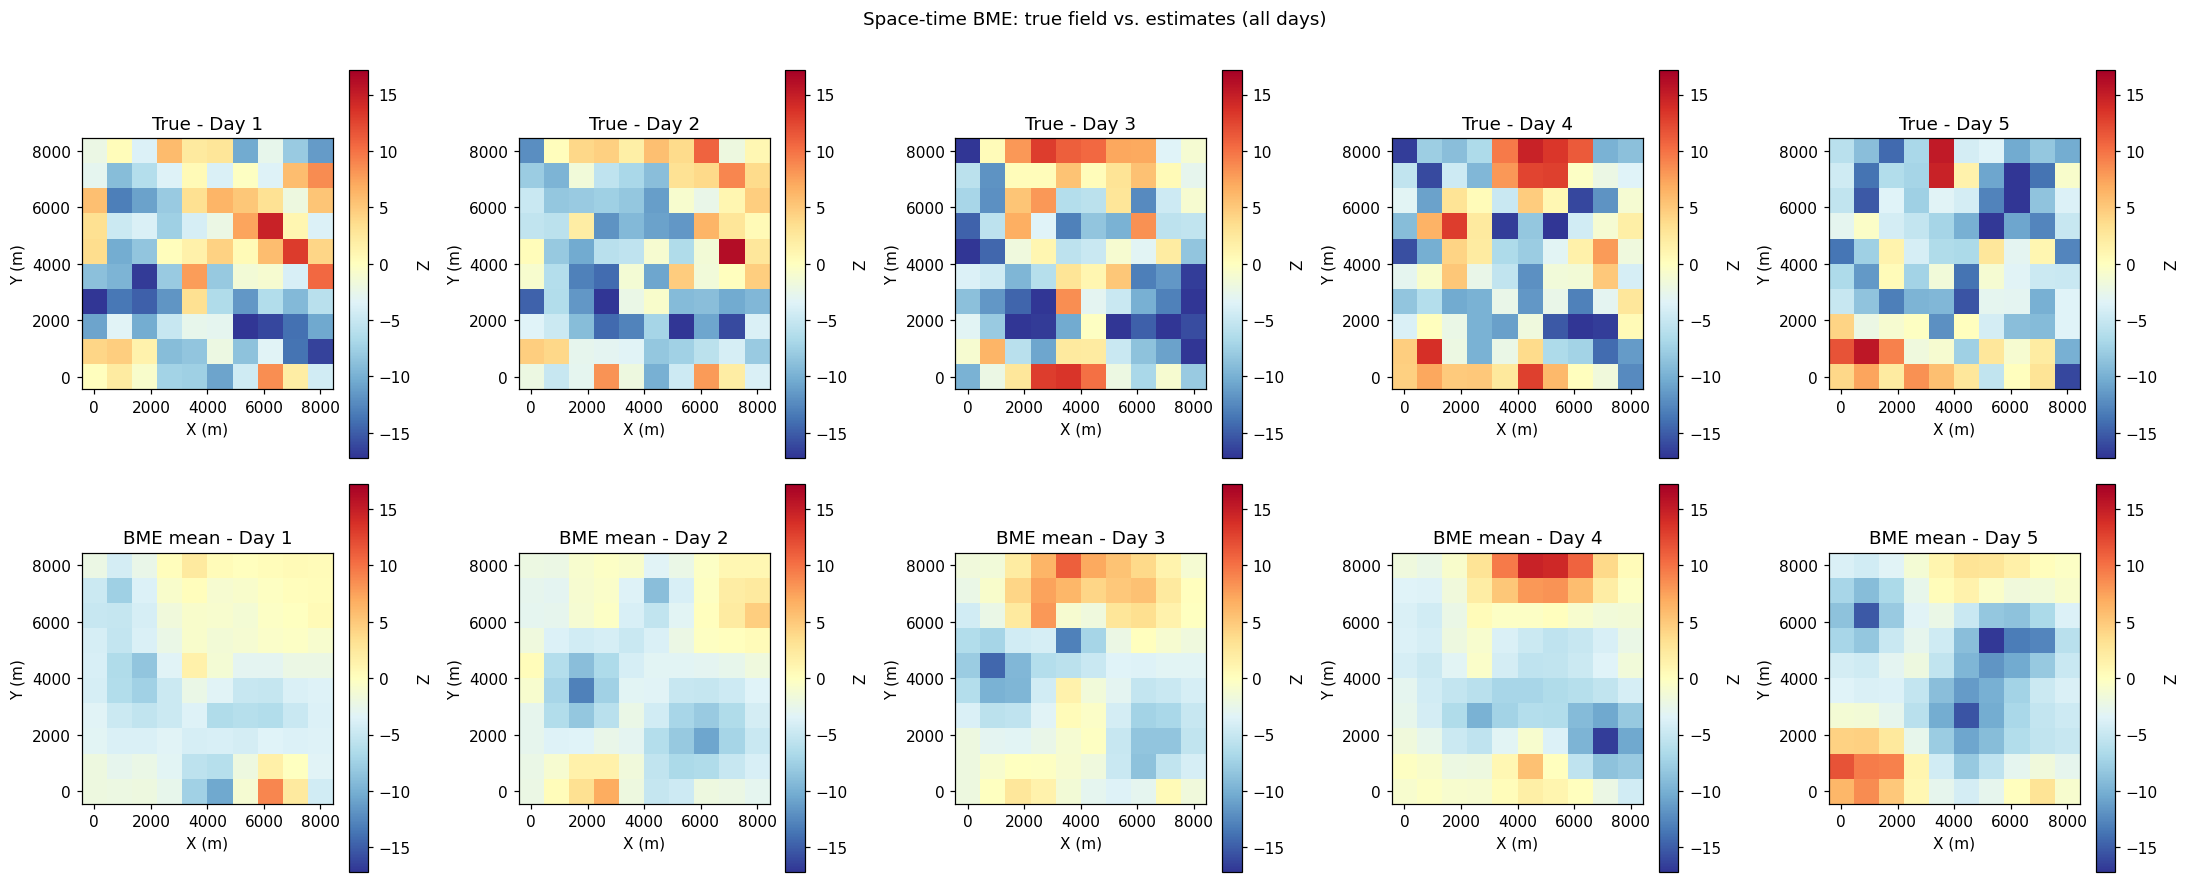

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for t_i, t_val in enumerate(times):
    # Estimation grid for this time slice
    ck_t = np.column_stack([
        spatial_grid,
        t_val * np.ones(n_space)
    ])
    res_t = BMEPosteriorMoments(
        ck_t,
        ch=ch_st, cs=cs_st,
        zh=zh_st.reshape(-1, 1),
        zs=tuple(zs_st),
        covmodel=covmodel_st,
        covparam=covparam_st,
        order=0,
        nhmax=nhmax_st, nsmax=nsmax_st,
        dmax=dmax_st,
    )
    # True field
    Z_true_t = Z_st[:, t_i]
    Z_bme_t  = res_t[:, 0]

    show_st_map(axes[0, t_i], Z_true_t,
                f'True - Day {int(t_val)}', vmin=-vz, vmax=vz)
    show_st_map(axes[1, t_i], Z_bme_t,
                f'BME mean - Day {int(t_val)}', vmin=-vz, vmax=vz)

plt.suptitle('Space-time BME: true field vs. estimates (all days)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 6. Effect of temporal neighbourhood

The temporal search radius `dmax_time` controls how much past and future observations influence the estimate.  A larger temporal window improves the estimate in areas with sparse data but may over-smooth temporal dynamics.

**Variance checkerboard pattern explained:**  
The BME variance map shows a "checkerboard" of low-variance (dark blue) and high-variance (white) cells. This is correct physics, not a bug:

| Situation | Temporal distance `h_t` | Temporal correlation | Residual variance |
|---|---|---|---|
| Hard data at exact same node (Day 3) | 0 | 1.0 | ≈ nugget ≈ 6 (dark blue) |
| Hard data 1 day away (Day 2 or 4) | 1 day | `exp(-1/2) ≈ 0.61` | ≈ 52 out of 75 (light blue) |
| No hard data within `dmax` | — | — | ≈ prior variance 75 (white) |

Filled red squares = Day 3 hard data → should be dark blue in the variance map.  
Hollow grey squares = Day 2 / Day 4 hard data → the **grid node at Day 3** is a *different space-time point*, so the variance at that spatial location is only partially reduced.


preparing...done
[STARBME] BME estimation: nk=100, nh=50, ns=20, soft types={2}, approx_gaussian=False
[STARBME] WARNING: Non-Gaussian soft data detected. Using QMC integration (slow). Enable 'Fast Gaussian Approximation' in Prediction > Configures for speed-up.


100 / 100
[STARBME] BME estimation completed in 1.4s (0.014s per point)
[STARBME] QMC noise diagnostic: delta_mu  median=0.003944, max=0.01722; rel_err  median=0.13%, max=0.86% (98 of 100 points had QMC error info)
preparing...done
[STARBME] BME estimation: nk=100, nh=50, ns=20, soft types={2}, approx_gaussian=False
[STARBME] WARNING: Non-Gaussian soft data detected. Using QMC integration (slow). Enable 'Fast Gaussian Approximation' in Prediction > Configures for speed-up.


100 / 100
[STARBME] BME estimation completed in 1.5s (0.015s per point)
[STARBME] QMC noise diagnostic: delta_mu  median=0.003983, max=0.01722; rel_err  median=0.13%, max=0.86% (98 of 100 points had QMC error info)
preparing...done
[STARBME] BME estimation: nk=100, nh=50, ns=20, soft types={2}, approx_gaussian=False
[STARBME] WARNING: Non-Gaussian soft data detected. Using QMC integration (slow). Enable 'Fast Gaussian Approximation' in Prediction > Configures for speed-up.


100 / 100
[STARBME] BME estimation completed in 1.4s (0.014s per point)
[STARBME] QMC noise diagnostic: delta_mu  median=0.004137, max=0.01722; rel_err  median=0.13%, max=0.86% (98 of 100 points had QMC error info)


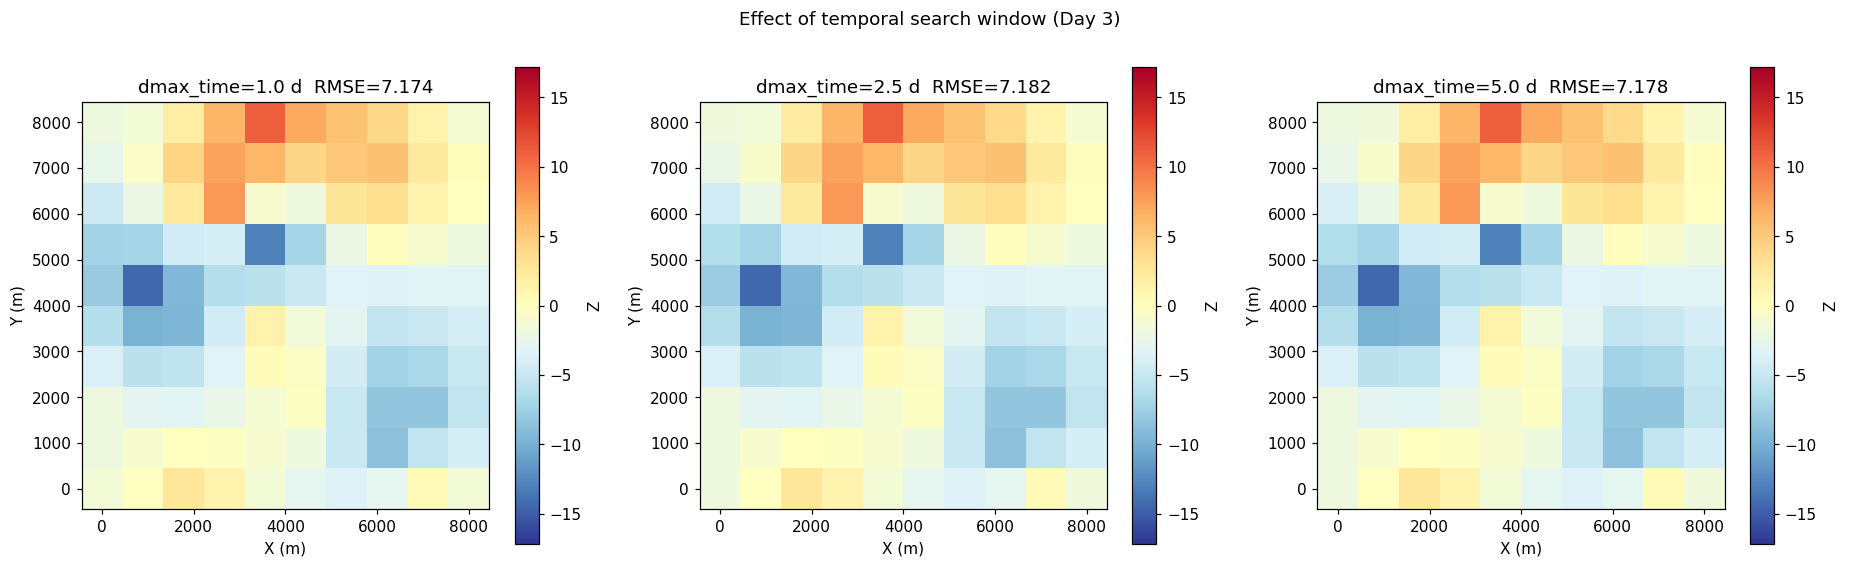

In [9]:
dmax_time_vals = [1.0, 2.5, 5.0]
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, dt_val in zip(axes, dmax_time_vals):
    res_dt = BMEPosteriorMoments(
        ck_st,
        ch=ch_st, cs=cs_st,
        zh=zh_st.reshape(-1, 1),
        zs=tuple(zs_st),
        covmodel=covmodel_st,
        covparam=covparam_st,
        order=0,
        nhmax=nhmax_st, nsmax=nsmax_st,
        dmax=np.array([[dmax_space, dt_val, st_ratio]]),
    )
    rmse_dt = np.sqrt(np.nanmean((res_dt[:, 0] - z_true_day3)**2))
    show_st_map(ax, res_dt[:, 0],
                f'dmax_time={dt_val:.1f} d  RMSE={rmse_dt:.3f}',
                vmin=-vz, vmax=vz)

plt.suptitle('Effect of temporal search window (Day 3)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 7. Summary

| Concept | stamps_v3 implementation |
|---|---|
| 3-D coordinates | `[x, y, t]` as 3-column array |
| Separable S/T covariance | e.g. `'nuggetC/nuggetC'`, `'sphericalC/exponentialC'` — params `(sill, ar_space, ar_time)` |
| Space-time neighbourhood | `dmax = [[dmax_space, dmax_time, st_ratio]]` — 3 elements required |
| `dmax_space` recommendation | `≈ 2 × a_s` (exclude decorrelated points) |
| Prior order | `order=0` (ordinary kriging) avoids zero-mean collapse |
| BME estimation | Same `BMEPosteriorMoments` as spatial case |

**Key insights:**
- The space-time BME framework is a direct generalisation of the spatial case.
- **Match the covariance model to the simulation**: using the wrong spatial model (e.g. `exponentialC` when data were generated with `sphericalC`) degrades accuracy.
- **Domain size matters**: keep the domain ≲ 3–4 × `a_s` per side, or increase data density proportionally.
- **`dmax_space ≈ 2 × a_s`**: a search radius much larger than the range includes decorrelated points that add noise rather than information.
- **`order=0`** (ordinary kriging) is preferred over `order=np.nan` (zero mean) when the field has an unknown or spatially varying mean.
- Data from nearby times (within `dmax_time`) are used as temporal neighbours.
- Increasing `dmax_time` borrows more information across time, reducing variance but potentially smoothing sharp temporal transitions.

**Next:** Tutorial 08 - Random field simulation.
